In [1]:
import xgi
import numpy as np
from tqdm import tqdm
from had_model import HAD_model
import matplotlib.pyplot as plt

# Generate or upload a hypergraph

Generate a random hypergraph

In [3]:
N = 300
ps = [1e-3, 1e-4, 1e-6]
H = xgi.fast_random_hypergraph(N, ps, seed=0)
H.cleanup()
print(H)
xgi.unique_edge_sizes(H), xgi.is_connected(H)

Unnamed Hypergraph with 300 nodes and 791 hyperedges


([2, 3, 4], True)

Or upload a real-world structure

In [20]:
with open('../data/SocioPatterns/aggr_15min_cliques_thr1_Thiers13.json') as file: 
            data = json.load(file)
H = xgi.from_hyperedge_list(data)
# relabel and remove eventual multiple edges
H.cleanup(isolates=True, singletons=True, connected=False)
N = len(H.nodes)

# Pairwise projections
#G = xgi.to_graph(H)
#H = xgi.Hypergraph(list(G.edges))

print(H)
xgi.unique_edge_sizes(H), xgi.is_connected(H)

Unnamed Hypergraph with 327 nodes and 4795 hyperedges


([2, 3, 4, 5, 6, 7], True)

## Simulate the process

In [23]:
epsilon = 0.1
Model = HAD_model(epsilon, H.edges.members())
results = Model.simulate()
T = len(results['groups'])

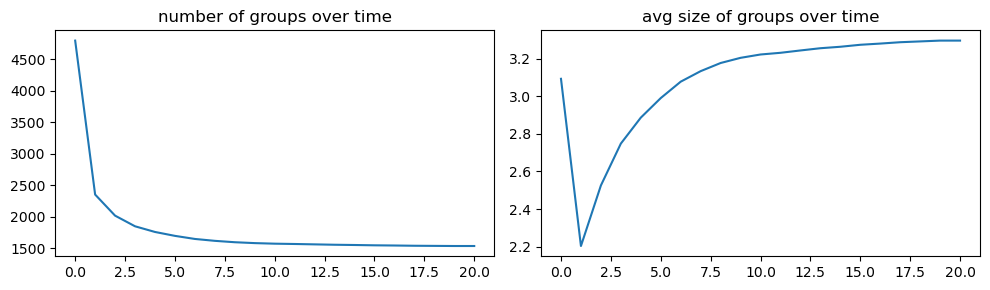

In [24]:
ng_t = [len(results['groups'][i]) for i in range(T)]
s_avg_t = []
for t in range(T):
    sizes_t = [len(group) for group in results['groups'][t]]
    s_avg_t.append(np.mean(sizes_t))

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].plot(ng_t)
axs[0].set_title('number of groups over time')
axs[1].plot(s_avg_t)
axs[1].set_title('avg size of groups over time')

plt.tight_layout()
plt.show()

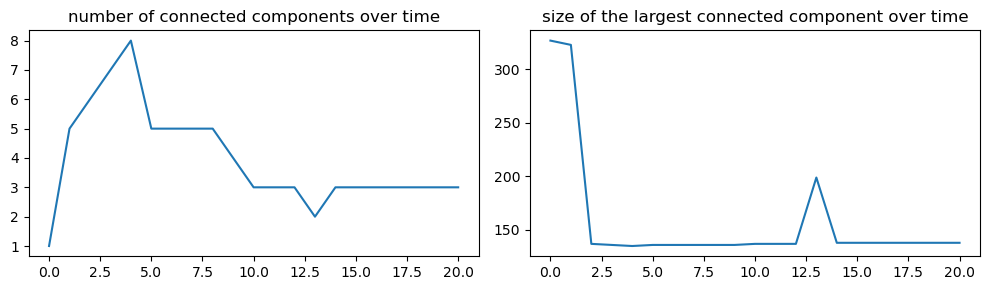

In [25]:
ncc = []
s_cc = []
for t in range(T):
    hedges = results['groups'][t]
    h = xgi.Hypergraph(hedges)
    # list of connected components
    cc = [j for j in xgi.connected_components(h)]
    ncc.append(len(cc))
    size_largest_cc = max([len(i) for i in cc])
    s_cc.append(size_largest_cc)

fig, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].plot(ncc)
axs[0].set_title('number of connected components over time')
axs[1].plot(s_cc)
axs[1].set_title('size of the largest connected component over time')

plt.tight_layout()
plt.show()

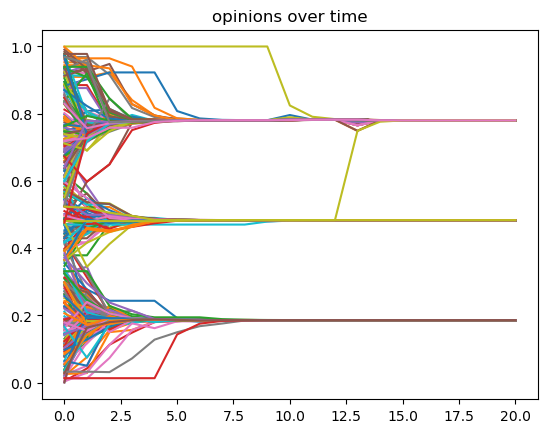

In [26]:
for n in H.nodes:
    plt.plot(results['opinions'][n])
plt.title('opinions over time')
plt.show()

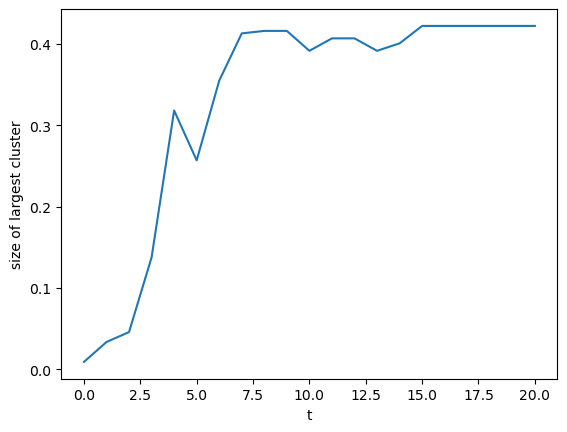

In [31]:
clst_size = []

for t in range(T):
    ops = [results['opinions'][n][t] for n in H.nodes]
    ops = np.round(ops, 3)
    x0 = 0
    # count max number of equal opinions (x0)
    for v in set(ops):
        x1 = sum(np.where(ops==v, 1, 0))
        if x1 > x0:
            x0 = x1
    clst_size.append(x0/N)

plt.plot(clst_size)
plt.ylabel('size of largest cluster')
plt.xlabel('t')
plt.show()

## Reproduce results for static hypergraphs

Reproduce fig.2 from this paper: https://www.nature.com/articles/s42005-022-00807-4

In [77]:
epsilons_space = np.linspace(0., 0.6, num=30)
N = 1024
orders = [2,3,4,5,6]
k = 10
seed = 0
# dict keyed by the the order of interaction, containing the list of cluster sizes (S) as a func of epsilon
clst_size = dict()

for d in orders:
    
    H = xgi.uniform_erdos_renyi_hypergraph(N, d, p=k, p_type='degree', seed=seed)
    H.cleanup()
    clst_size[d] = []
    for epsilon in tqdm(epsilons_space):
        Model = HAD_model(epsilon, H.edges.members())
        opinions = Model.simulate(condition='max_min', adaptive=False)['opinions']
        # compute relative size of largest opinion cluster
        aa = []
        for n in range(N):
            # list of opinions at last time step
            aa.append( np.round(opinions[n][-1], 4) )       
        aa = np.array(aa)
        x0 = 0
        # count max number of equal opinions (x0)
        for v in set(aa):
            x1 = sum(np.where(aa==v, 1, 0))
            if x1 > x0:
                x0 = x1
        clst_size[d].append(x0/N)

100%|███████████████████████████████████████████████| 30/30 [00:24<00:00,  1.21it/s]


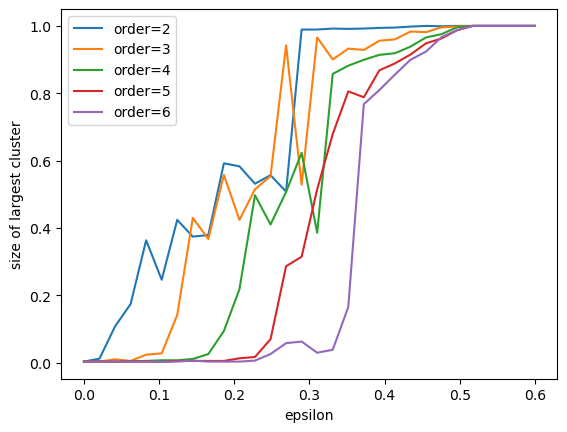

In [78]:
for d in orders:
    plt.plot(epsilons_space, clst_size[d], label=f'order={d}')
plt.ylabel('size of largest cluster')
plt.xlabel('epsilon')
plt.legend()
plt.show()

### What happens if we use the standard deviation instead of the max-min as a condition for agreement?

In [80]:
epsilons_space = np.linspace(0., 0.6, num=20)
N = 1024
orders = [2,3,4,5,6]
k = 10
seed = 0
# dict keyed by the the order of interaction, containing the list of cluster sizes (S) as a func of epsilon
clst_size = dict()

for d in orders:
    
    H = xgi.uniform_erdos_renyi_hypergraph(N, d, p=k, p_type='degree', seed=seed)
    H.cleanup()
    clst_size[d] = []
    for epsilon in tqdm(epsilons_space):
        Model = HAD_model(epsilon, H.edges.members())
        opinions = Model.simulate(adaptive=False)['opinions']
        # compute relative size of largest opinion cluster
        aa = []
        for n in range(N):
            # list of opinions at last time step
            aa.append( np.round(opinions[n][-1], 4) )       
        aa = np.array(aa)
        x0 = 0
        # count max number of equal opinions (x0)
        for v in set(aa):
            x1 = sum(np.where(aa==v, 1, 0))
            if x1 > x0:
                x0 = x1
        clst_size[d].append(x0/N)

100%|███████████████████████████████████████████████| 20/20 [01:07<00:00,  3.37s/it]


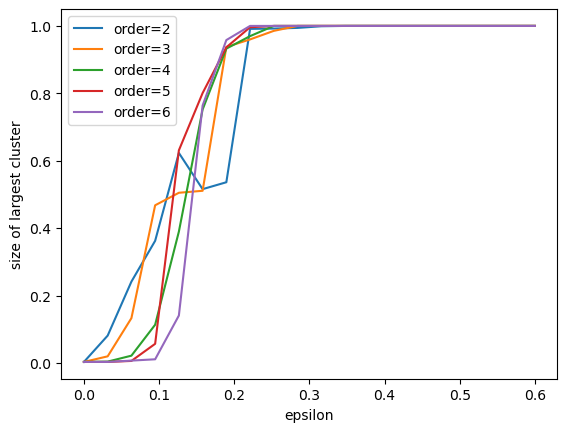

In [81]:
for d in orders:
    plt.plot(epsilons_space, clst_size[d], label=f'order={d}')
plt.ylabel('size of largest cluster')
plt.xlabel('epsilon')
plt.legend()
plt.show()